In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os 
import sys

In [2]:
''' File Paths '''
root_dir = "Z:/Isabel/data/hpc_implants/"
save_figs_dir = f"../figures/basic_neural_analysis/"
data_file = f"{root_dir}stim_session_data.npy"
session_info_file = f"{root_dir}good_sessions.xlsx"

''' Load the data dictionary and get bird ids '''
data_dict = np.load(data_file, allow_pickle=True).item()
bird_ids = []
data_dict = np.load(data_file, allow_pickle=True).item()
for bird in data_dict.keys():
    bird_ids.append(bird)

# remove birds with no histology/behavior sessions
no_hist = ['RBY94', 'LIM63']
bird_ids = np.setdiff1d(bird_ids, no_hist)

In [5]:
data_dict['SLV132']['250310'].keys()

dict_keys(['preprocessed_data', 'ephys_id', 'waveform_props', 'pred_date', 'worm_ch_idx', 'depth', 'channel_pos', 'cell_pos', 'barcode_dict', 'excitatory_idx', 'inhibitory_idx', 'stim_resp_idx_ch', 'nucleus_dvs', 'shank_A_idx'])

In [3]:
''' Make session list '''
pos_sessions = []
behavior_sessions = []
for i, bird in enumerate(bird_ids):
    for session_id in data_dict[bird]['all_sessions']:
        if 'cell_pos' in data_dict[bird][session_id].keys():
            pos_sessions.append(f'{bird}_{session_id}')
        preprocessed_data = data_dict[bird][session_id]['preprocessed_data']
        if ('behavior' in preprocessed_data) & ('ephys' in preprocessed_data):
            behavior_sessions.append(f'{bird}_{session_id}')
sessions_to_use = list(set(pos_sessions) & set (behavior_sessions))


In [4]:
''' Collect data across sessions for each bird '''
pos_dict = {}
all_AP = np.asarray([])
for i, bird in enumerate(bird_ids):
    pos_dict[bird] = {}
    for session_id in data_dict[bird]['all_sessions']:
        if f'{bird}_{session_id}' in sessions_to_use:
            # get the position of each cell (ML, est AP, DV)
            cell_pos = data_dict[bird][session_id]['cell_pos']
            
            # get the waveform props (asymm, width, log_fr)
            waveform_props = data_dict[bird][session_id]['waveform_props']

            # get the active cache fraction
            active_cache_frac = data_dict[bird][session_id]['barcode_dict']['active_cache_frac']

            # index cells by stim responsive channels
            stim_idx = data_dict[bird][session_id]['stim_resp_idx_ch']
            ch_pos = data_dict[bird][session_id]['channel_pos']
            stim_pos = ch_pos[stim_idx]
            n_cells = cell_pos.shape[0]
            cell_stim_idx = np.zeros(n_cells)
            for cell_idx, this_pos in enumerate(cell_pos):
                cell_stim_idx[cell_idx] = np.any(np.all(stim_pos == this_pos, axis=1))

            # excitatory/inhibitory indices
            exc_idx = data_dict[bird][session_id]['excitatory_idx']
            inhib_idx = data_dict[bird][session_id]['inhibitory_idx']
            
            # store for this bird
            if 'cell_pos' in pos_dict[bird].keys():
                pos_dict[bird]['cell_pos'] = np.row_stack((pos_dict[bird]['cell_pos'], cell_pos))
                pos_dict[bird]['waveform_props'] = np.column_stack((pos_dict[bird]['waveform_props'], waveform_props))     
                pos_dict[bird]['active_cache_frac'] = np.append(pos_dict[bird]['active_cache_frac'], active_cache_frac)
                pos_dict[bird]['cell_stim_idx'] = np.append(pos_dict[bird]['cell_stim_idx'], cell_stim_idx.astype(bool))
                pos_dict[bird]['excitatory_idx'] = np.append(pos_dict[bird]['excitatory_idx'], exc_idx.astype(bool))
                pos_dict[bird]['inhibitory_idx'] = np.append(pos_dict[bird]['inhibitory_idx'], inhib_idx.astype(bool))
            else:
                pos_dict[bird]['cell_pos'] = cell_pos
                pos_dict[bird]['waveform_props'] = waveform_props
                pos_dict[bird]['active_cache_frac'] = active_cache_frac
                pos_dict[bird]['cell_stim_idx'] = cell_stim_idx.astype(bool)
                pos_dict[bird]['excitatory_idx'] = exc_idx.astype(bool)
                pos_dict[bird]['inhibitory_idx'] = inhib_idx.astype(bool)
                
                # get the AP position of each shank
                cell_AP = np.unique(cell_pos[:, 1])
                shank_AP = np.zeros(2)
                shank_AP[0] = np.mean(cell_AP[:3])
                shank_AP[1] = np.mean(cell_AP[3:])
                pos_dict[bird]['AP'] = shank_AP
    
    # store the AP values and waveform props for all birds
    all_AP = np.append(all_AP, pos_dict[bird]['AP'])
    if i == 0:
        all_waveform_props = pos_dict[bird]['waveform_props']
    else:
        all_waveform_props = np.column_stack((all_waveform_props, pos_dict[bird]['waveform_props']))

In [15]:
bird = 'AMB154'

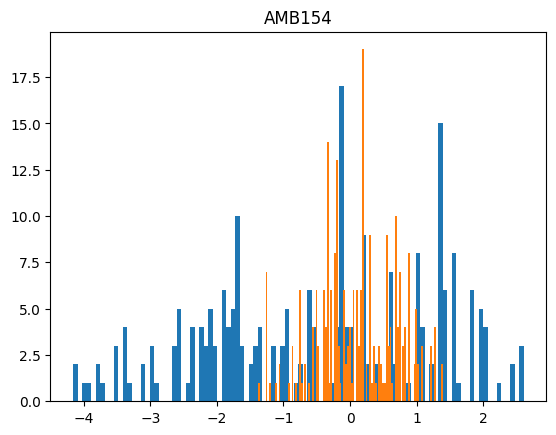

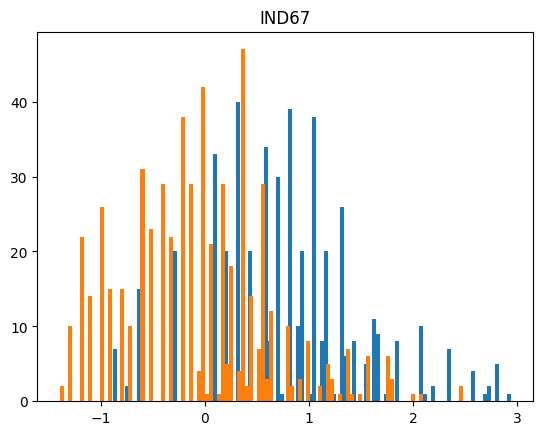

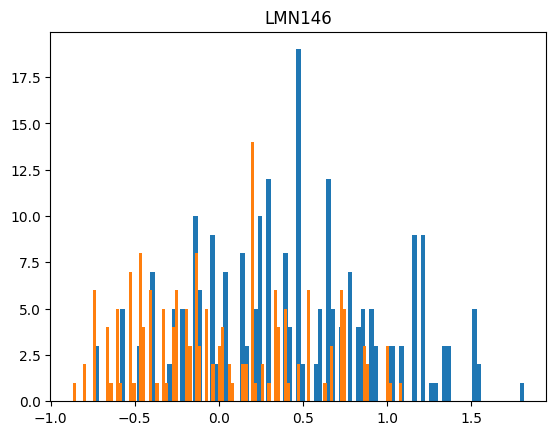

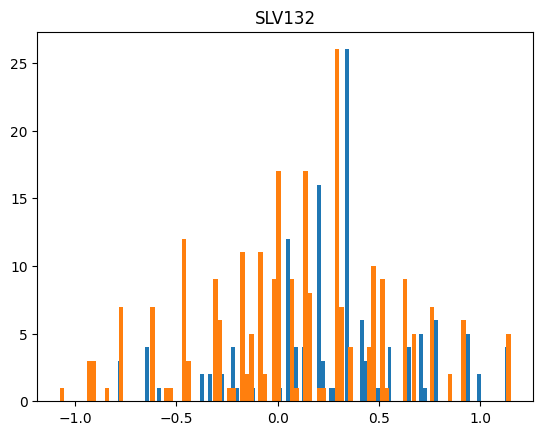

In [6]:
''' Normalize DV by relative position in nucleus
call center 0, shallow end -1, deep end 1
everything < -1 is DL
everything > 1 is the rest of the hippocampus...
'''
for bird in bird_ids:
    # nucleus boundaries - A min, A max; B min, B max
    nucleus_dvs = data_dict[bird]['nucleus_dvs'].copy()
    A_nuc_lims = nucleus_dvs[0]
    B_nuc_lims = nucleus_dvs[1]
    A_nuc_center = np.mean(A_nuc_lims)
    B_nuc_center = np.mean(B_nuc_lims)
    
    # positions
    cell_pos = pos_dict[bird]['cell_pos'].copy()
    cell_dv = cell_pos[:, -1]
    _, ap_idx = np.unique(cell_pos[:, 1], return_inverse=True)
    B_idx = ap_idx < 3
    A_idx = ap_idx >= 3
    
    # separate by shank and normalize
    A_dv = cell_dv[A_idx]
    B_dv = cell_dv[B_idx]
    A_dv_norm = (A_dv - A_nuc_center) / (A_nuc_lims[1] - A_nuc_center)
    B_dv_norm = (B_dv - B_nuc_center) / (B_nuc_lims[1] - B_nuc_center)

    plt.hist(A_dv_norm, bins=100)
    plt.hist(B_dv_norm, bins=100)
    plt.title(bird)
    plt.show()

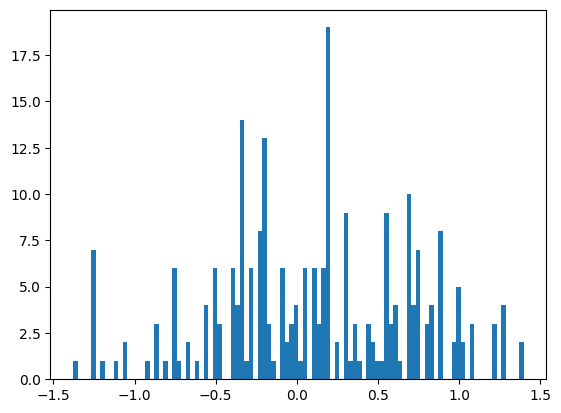

In [17]:
plt.hist(B_dv_norm, bins=100)
plt.show()


In [7]:
session_dir = f'{root_dir}{bird}/{bird}_{session_id}/'
for file in sorted(os.listdir(f"{session_dir}{bird}_{ephys_id}")):
    if 'kilosort4' in file:
        ks_dir = f"{bird}_{ephys_id}/{file}/"
ch_pos_probe = np.load(f"{session_dir}{ks_dir}channel_positions.npy")

NameError: name 'session_dir' is not defined